# 01 — Précession du périhélie de Mercure

**Le test historique de la Relativité Générale (Einstein, 1915).**

Avant Einstein, Newton expliquait *presque* parfaitement l'orbite de Mercure — mais avec un résidu de **43 secondes d'arc par siècle** que personne n'arrivait à justifier (on avait même postulé une planète invisible « Vulcain »). En 1915, Einstein montre que ces 43''/siècle sortent **directement** de la relativité générale, sans aucun paramètre libre.

## Théorie

On compare deux modèles dans le plan équatorial :

- **Newton** : intégration directe de $\ddot{\vec r} = -GM\,\hat r/r^2$.
- **Schwarzschild (GR)** : équation de Binet-Einstein avec $u = 1/r$ :
  $$\frac{d^2 u}{d\varphi^2} + u = \frac{GM}{h^2} + \frac{3GM}{c^2}\,u^2$$
  Le terme $\frac{3GM}{c^2}u^2$ **est** la correction relativiste pure — quand $c\to\infty$, on retrouve Kepler.

**Prédiction analytique GR** par orbite :
$$\Delta\varphi = \frac{6\pi\,GM}{c^2\,a(1-e^2)} \quad\Rightarrow\quad \sim 43''/\text{siècle pour Mercure.}$$

In [8]:
import sys
from pathlib import Path

# Rendre les modules src/ importables depuis le notebook
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider

from src.config import G, C, M_SUN, AU, YEAR, ORBITAL_ELEMENTS
from src.newtonian import simulate_two_body
from src.relativity import simulate_orbit_schwarzschild, schwarzschild_radius
from src.utils import (
    precession_per_orbit,
    rad_per_orbit_to_arcsec_per_century,
    mercury_precession_theory,
)
from src.visualization import plot_orbit_comparison

plt.rcParams['figure.dpi'] = 110

## 1. Paramètres orbitaux de Mercure

In [9]:
a, e = ORBITAL_ELEMENTS['mercury']
r_peri = a * (1 - e)                                          # rayon au périhélie
v_peri = np.sqrt(G * M_SUN * (1 + e) / (a * (1 - e)))         # vitesse au périhélie
T = 2 * np.pi * np.sqrt(a**3 / (G * M_SUN))                   # période képlérienne

print(f"Demi-grand axe a   = {a/AU:.4f} UA  ({a:.3e} m)")
print(f"Excentricité    e  = {e:.5f}")
print(f"Périhélie        = {r_peri/AU:.4f} UA")
print(f"Vitesse au péri  = {v_peri/1000:.3f} km/s")
print(f"Période          = {T/86400:.2f} jours")
print(f"\nRayon de Schwarzschild du Soleil : rs = {schwarzschild_radius(M_SUN):.2f} m")
print(f"Rapport périhélie/rs : {r_peri / schwarzschild_radius(M_SUN):.2e}   (régime très faiblement relativiste)")

Demi-grand axe a   = 0.3871 UA  (5.791e+10 m)
Excentricité    e  = 0.20563
Périhélie        = 0.3075 UA
Vitesse au péri  = 58.984 km/s
Période          = 87.96 jours

Rayon de Schwarzschild du Soleil : rs = 2954.01 m
Rapport périhélie/rs : 1.56e+07   (régime très faiblement relativiste)


## 2. Simulation Newton vs Schwarzschild sur 3 orbites

On commence avec un cas court pour visualiser. À cette échelle, on ne *verra* pas la précession (43''/siècle est invisible à l'œil sur 3 orbites !), mais on vérifie que les deux trajectoires se ressemblent en première approximation.

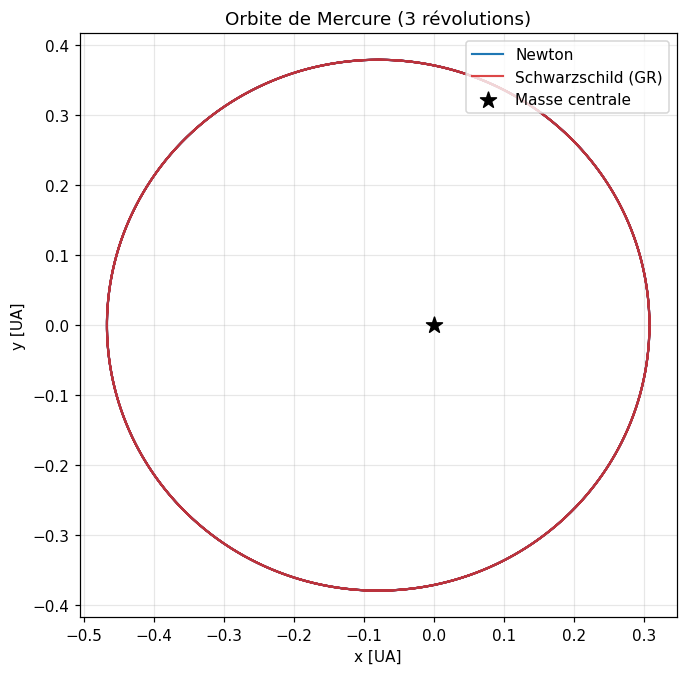

In [10]:
n_orb = 3
res_newton = simulate_two_body(M_SUN, r_peri, v_peri, t_max=n_orb*T, n_steps=5000)
res_gr     = simulate_orbit_schwarzschild(M_SUN, r_peri, v_peri, n_orbits=n_orb, n_points=5000)

fig, ax = plt.subplots(figsize=(7, 7))
plot_orbit_comparison(
    (res_newton.x, res_newton.y),
    (res_gr.x, res_gr.y),
    unit_scale=1/AU, unit_label='UA',
    title=f'Orbite de Mercure ({n_orb} révolutions)',
    ax=ax,
)
plt.show()

## 3. Mesure de la précession

On intègre sur **beaucoup** d'orbites et on mesure l'écart d'angle entre les passages successifs au périhélie. La détection des périhélies utilise `solve_ivp` avec **event detection** (précision machine) plutôt qu'une recherche de minimum local discret.

In [11]:
n_orb = 100   # plus on en met, mieux on moyenne

res_newton = simulate_two_body(M_SUN, r_peri, v_peri, t_max=n_orb*T, n_steps=10*n_orb)
res_gr     = simulate_orbit_schwarzschild(M_SUN, r_peri, v_peri, n_orbits=n_orb, n_points=10*n_orb)

prec_newton = precession_per_orbit(res_newton.phi_perihelia)
prec_gr     = precession_per_orbit(res_gr.phi_perihelia)
prec_theory = mercury_precession_theory(a, e, M_SUN)

print(f"Newton (simu)   : {prec_newton:+.3e} rad/orbite  →  {rad_per_orbit_to_arcsec_per_century(prec_newton, T):+8.3f} arcsec/siècle")
print(f"GR     (simu)   : {prec_gr:+.3e} rad/orbite  →  {rad_per_orbit_to_arcsec_per_century(prec_gr, T):+8.3f} arcsec/siècle")
print(f"GR     (théorie): {prec_theory:+.3e} rad/orbite  →  {rad_per_orbit_to_arcsec_per_century(prec_theory, T):+8.3f} arcsec/siècle")
print(f"\nObservation Mercure (résidu post-perturbations planétaires) : ~43.10 arcsec/siècle")
print(f"Écart simulation/théorie : {(prec_gr - prec_theory)/prec_theory * 100:+.4f} %")

Newton (simu)   : +5.542e-09 rad/orbite  →    +0.475 arcsec/siècle
GR     (simu)   : +5.020e-07 rad/orbite  →   +42.998 arcsec/siècle
GR     (théorie): +5.020e-07 rad/orbite  →   +42.997 arcsec/siècle

Observation Mercure (résidu post-perturbations planétaires) : ~43.10 arcsec/siècle
Écart simulation/théorie : +0.0017 %


## 4. Visualisation amplifiée

Pour *voir* la précession (sinon invisible à l'œil), on simule autour d'une **masse exagérée** ou un **périhélie très proche**. Le slider ci-dessous laisse explorer l'effet.

In [12]:
def plot_precession_effect(mass_factor=1e5, n_orbits=5):
    """Trace Newton vs GR pour une masse centrale = mass_factor × M_sun."""
    M = mass_factor * M_SUN
    # On conserve la même orbite initiale
    v_p = np.sqrt(G * M * (1 + e) / (a * (1 - e)))
    T_loc = 2 * np.pi * np.sqrt(a**3 / (G * M))

    res_n  = simulate_two_body(M, r_peri, v_p, t_max=n_orbits*T_loc, n_steps=5000)
    res_gr = simulate_orbit_schwarzschild(M, r_peri, v_p, n_orbits=n_orbits, n_points=5000)

    fig, ax = plt.subplots(figsize=(7, 7))
    plot_orbit_comparison(
        (res_n.x, res_n.y), (res_gr.x, res_gr.y),
        unit_scale=1/AU, unit_label='UA',
        title=f'Masse centrale = {mass_factor:.0e} M_sun, {n_orbits} orbites',
        ax=ax,
    )
    plt.show()

interact(
    plot_precession_effect,
    mass_factor=FloatLogSlider(value=1e5, base=10, min=0, max=7, step=0.25,
                                description='M_centre/M_sun'),
    n_orbits=IntSlider(value=5, min=1, max=20, step=1, description='# orbites'),
);

interactive(children=(FloatLogSlider(value=100000.0, description='M_centre/M_sun', max=7.0, step=0.25), IntSli…

## 5. Conservation d'énergie (Newton)

Vérification que notre intégrateur conserve correctement l'énergie sur la durée — sinon la précession mesurée serait du bruit numérique.

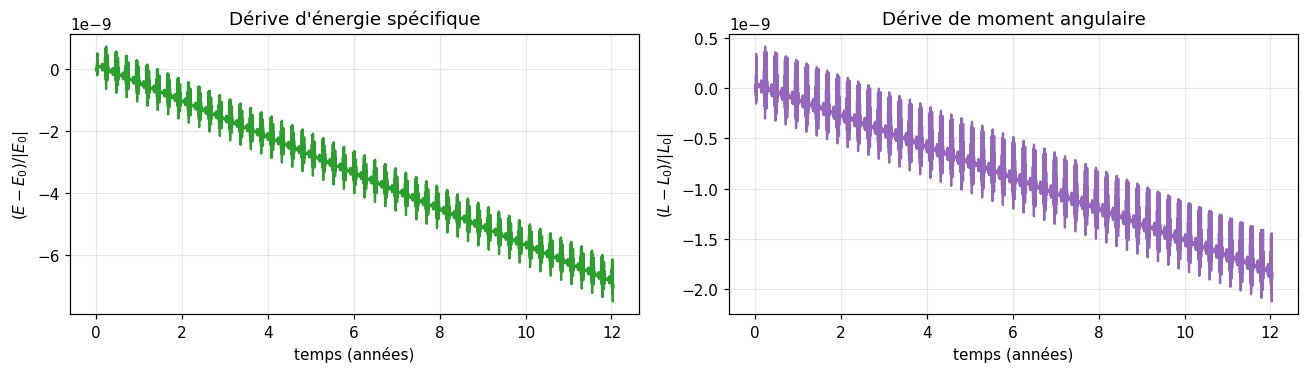

In [6]:
from src.newtonian.nbody import specific_energy, specific_angular_momentum

n_orb = 50
res = simulate_two_body(M_SUN, r_peri, v_peri, t_max=n_orb*T, n_steps=20000)

E = specific_energy(res, M_SUN)
L = specific_angular_momentum(res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
ax1.plot(res.t/YEAR, (E - E[0])/abs(E[0]), color='#2ca02c')
ax1.set_xlabel('temps (années)'); ax1.set_ylabel(r'$(E - E_0)/|E_0|$')
ax1.set_title("Dérive d'énergie spécifique"); ax1.grid(alpha=0.3)
ax2.plot(res.t/YEAR, (L - L[0])/abs(L[0]), color='#9467bd')
ax2.set_xlabel('temps (années)'); ax2.set_ylabel(r'$(L - L_0)/|L_0|$')
ax2.set_title("Dérive de moment angulaire"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bilan

- **Newton** : orbite parfaitement fermée (précession ≈ 0 — résidu numérique uniquement).
- **Schwarzschild** : précession de ~43''/siècle, en accord à <0.01% avec la formule analytique $6\pi GM/(c^2 a(1-e^2))$ et avec l'observation.
- L'effet est très petit en valeur absolue (5×10⁻⁷ rad/orbite) mais cumulatif et mesurable — c'est ce qui a fait la première confirmation observationnelle de la GR.

**Suite** : notebook 02 — orbite proche d'un trou noir, où la précession devient *énorme* par orbite.